In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

import joblib
 # chargement de dataset 
data = pd.read_csv("german.data", sep=' ', header=None)
columns = [
    "checking_status","duration","credit_history","purpose","credit_amount",
    "savings_status","employment","installment_commitment","personal_status",
    "other_parties","residence_since","property_magnitude","age",
    "other_payment_plans","housing","existing_credits","job",
    "num_dependents","own_telephone","foreign_worker","class"
]
data.columns = columns


In [54]:
data['class'] = data['class'].map({1: 0, 2: 1})

In [55]:
data.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


In [56]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   checking_status         1000 non-null   object
 1   duration                1000 non-null   int64 
 2   credit_history          1000 non-null   object
 3   purpose                 1000 non-null   object
 4   credit_amount           1000 non-null   int64 
 5   savings_status          1000 non-null   object
 6   employment              1000 non-null   object
 7   installment_commitment  1000 non-null   int64 
 8   personal_status         1000 non-null   object
 9   other_parties           1000 non-null   object
 10  residence_since         1000 non-null   int64 
 11  property_magnitude      1000 non-null   object
 12  age                     1000 non-null   int64 
 13  other_payment_plans     1000 non-null   object
 14  housing                 1000 non-null   object
 15  exist

In [57]:
 # statistiques descriptives
data.describe()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,class
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,0.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,0.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,0.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,0.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,1.000000


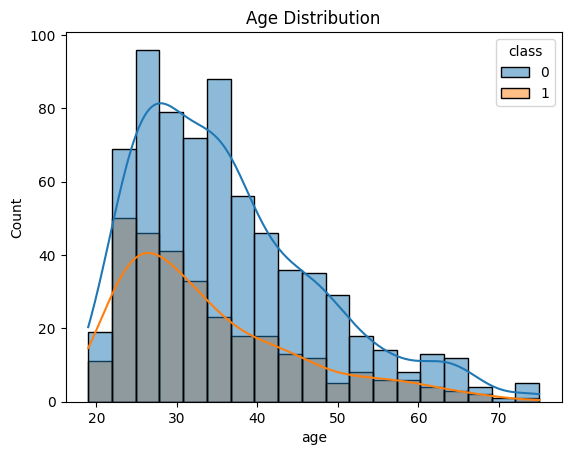

In [58]:
 # distrubition de l'age des clients 

df_plot = data.copy()
#Pour éviter de modifier le DataFrame original.
sns.histplot(data=df_plot, x='age', hue='class', kde=True)
plt.title("Age Distribution")
plt.show()

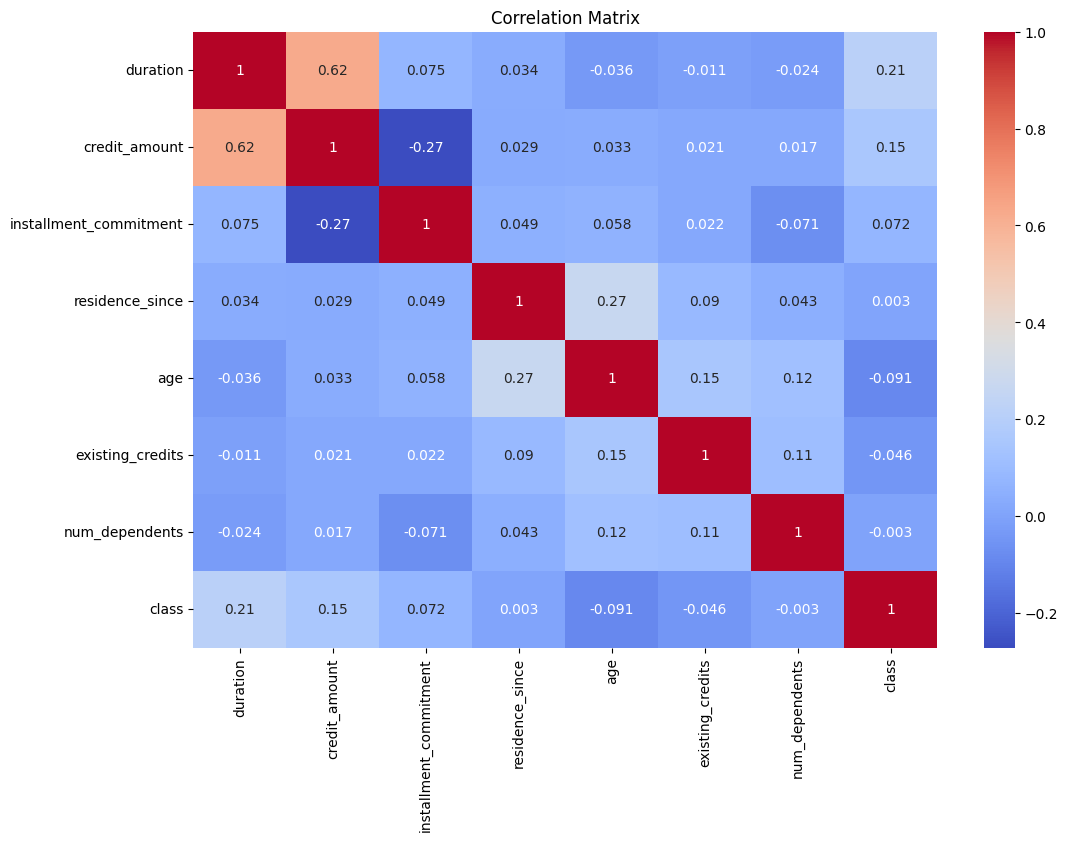

In [59]:
plt.figure(figsize=(12,8))

corr = data.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

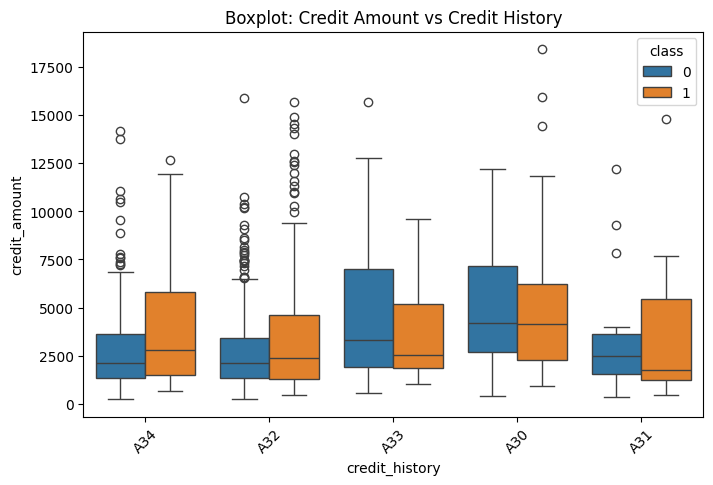

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt
#Box plit pour comparer le montant de crédit selon l'historique de crédit de client 
plt.figure(figsize=(8,5))

sns.boxplot(
    x="credit_history",
    y="credit_amount",
    hue="class",   # cible (0 = bon, 1 = mauvais)
    data=data
)

plt.title("Boxplot: Credit Amount vs Credit History")
plt.xticks(rotation=45)
plt.show()

In [61]:
print(data.isnull().sum())

data['age'] = data['age'].fillna(data['age'].median())
data['purpose'] = data['purpose'].fillna(data['purpose'].mode()[0])

checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
class                     0
dtype: int64


In [62]:
# FEATURE ENGINEERING
data['age_group'] = data['age'] // 10

data['credit_per_duration'] = data['credit_amount'] / (data['duration'] + 1)

data['high_credit'] = (
    data['credit_amount'] > data['credit_amount'].mean()
).astype(int)

data['long_term_credit'] = (
    data['duration'] > data['duration'].median()
).astype(int)

In [63]:
# ENCODING
data = pd.get_dummies(data, drop_first=True)

In [64]:
#  SPLIT DATA
X = data.drop('class', axis=1)
y = data['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [65]:
scaler = StandardScaler()
num_cols = ['age', 'credit_amount', 'duration']
num_cols = [col for col in num_cols if col in X_train.columns]

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [66]:
print("✅ DATA READY FOR MODELING")

✅ DATA READY FOR MODELING


In [67]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [68]:
y_pred = model.predict(X_test)

In [69]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [70]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", svm.score(X_test, y_test))

SVM Accuracy: 0.7


In [71]:
from xgboost import XGBClassifier

xgb = XGBClassifier()

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", xgb.score(X_test, y_test))

XGBoost Accuracy: 0.795


In [72]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Pipeline : Scaling + Logistic Regression
pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)

# Cross Validation
scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5
)

# Résultats
print("Scores de chaque fold :", scores)

print("Accuracy moyenne :", scores.mean())

Scores de chaque fold : [0.745 0.77  0.75  0.755 0.735]
Accuracy moyenne : 0.751


Accuracy : 0.79
F1-Score : 0.5961538461538461
AUC : 0.8139199423007574

Confusion Matrix :
[[127  14]
 [ 28  31]]


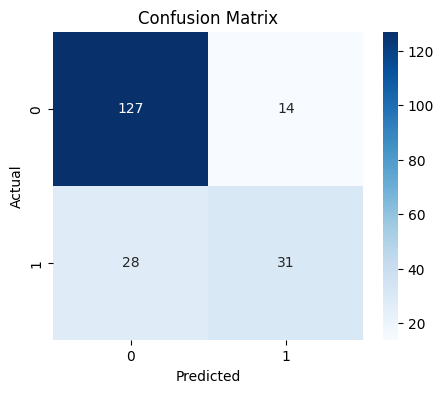

In [73]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================
# 1. ENTRAÎNEMENT DU MODÈLE
# ==============================
model.fit(X_train, y_train)

# ==============================
# 2. PRÉDICTIONS
# ==============================
y_pred = model.predict(X_test)

# Probabilités (pour AUC)
y_proba = model.predict_proba(X_test)[:, 1]

# ==============================
# 3. MÉTRIQUES DE CLASSIFICATION
# ==============================

print("Accuracy :", accuracy_score(y_test, y_pred))
print("F1-Score :", f1_score(y_test, y_pred))
print("AUC :", roc_auc_score(y_test, y_proba))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix :")
print(cm)


# ==============================
# 4. VISUALISATION
# ==============================
plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [74]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ==============================
# 1. PRÉDICTIONS DU MODÈLE
# ==============================
y_pred = model.predict(X_test)

# ==============================
# 2. MAE (Mean Absolute Error)
# ==============================
mae = mean_absolute_error(y_test, y_pred)

# ==============================
# 3. RMSE (Root Mean Squared Error)
# ==============================
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# ==============================
# 4. R² SCORE
# ==============================
r2 = r2_score(y_test, y_pred)

# ==============================
# 5. AFFICHAGE DES RÉSULTATS
# ==============================
print("MAE :", mae)
print("RMSE :", rmse)
print("R² Score :", r2)

MAE : 0.21
RMSE : 0.458257569495584
R² Score : -0.009736747205192797


In [36]:
import joblib

# sauvegarde du modèle
joblib.dump(model, "credit_model.pkl")

# sauvegarde du scaler
joblib.dump(scaler, "scaler.pkl")

print(" fichiers .pkl créés avec succès")

 fichiers .pkl créés avec succès


In [37]:
joblib.dump(model, "credit_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [38]:
import os
print(os.listdir())



['.ipynb_checkpoints', '.venv', 'app.py', 'credit_model.pkl', 'german.data', 'scaler.pkl', 'selected_features.pkl', 'test.ipynb', '__pycache__']


In [39]:
model = joblib.load(r"C:\Users\user\Desktop\Projet credit prediction\credit_model.pkl")
scaler = joblib.load(r"C:\Users\user\Desktop\Projet credit prediction\scaler.pkl")


In [40]:
model = joblib.load("credit_model.pkl")
scaler = joblib.load("scaler.pkl")


In [41]:
import joblib

model = joblib.load("credit_model.pkl")
scaler = joblib.load("scaler.pkl")


In [42]:

selected_features = list(data.drop('class', axis=1).columns)

joblib.dump(selected_features, "selected_features.pkl")
print(" selected_features.pkl sauvegardé")

 selected_features.pkl sauvegardé


In [43]:
import os
print(os.listdir())



['.ipynb_checkpoints', '.venv', 'app.py', 'credit_model.pkl', 'german.data', 'scaler.pkl', 'selected_features.pkl', 'test.ipynb', '__pycache__']
